# Test połączenia korekcji gamma z augmentacją oświetleniową

Celem eksperymentu jest określenie, czy połączenie korekcji gamma γ = 1.5 z najlepiej ocenioną konfiguracją augmentacji oświetleniowej zwiększa odporność modelu ResNet50 na trudne warunki oświetleniowe.

Na podstawie wcześniejszych eksperymentów wybrano konfigurację `lighting_strong_dark`, obejmującą losową zmianę jasności w zakresie 0.3–1.3 oraz zmianę kontrastu w zakresie 0.8–1.2 z prawdopodobieństwem 0.8.

Porównane zostaną dwie konfiguracje:

- `lighting_strong_dark`,
- `lighting_strong_dark + gamma_1.5`.

Pozostałe elementy procesu uczenia pozostają identyczne:

- architektura `ResNet50`,
- wagi ImageNet,
- `WeightedRandomSampler`,
- funkcja Cross Entropy,
- podział danych,
- parametry optymalizacji.

Etap ma charakter przesiewowy i wykorzystuje 5 epok treningu przy zamrożonym backbone oraz 2 epoki fine-tuningu.

Podstawowym kryterium wyboru jest średnia wartość `Macro F1` dla wariantów `dark_1`, `dark_2` i `dark_3` na zbiorze walidacyjnym.

Zbiór `test_final` nie jest wykorzystywany do wyboru konfiguracji.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.preprocessing import (
    gamma_correction,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "gamma_lighting_combination"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
FROZEN_EPOCHS = 5
FINE_TUNE_EPOCHS = 2
FROZEN_LR = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_SEED = 42
PRETRAINED = True
GAMMA_VALUE = 1.5

CONFIGURATIONS = [
    {
        "name": "lighting_strong_dark",

        "use_gamma": False,

        "gamma": None,
    },

    {
        "name": "lighting_strong_dark_gamma_1.5",

        "use_gamma": True,

        "gamma": GAMMA_VALUE,
    },
]


DARK_VARIANTS = [
    "dark_1",
    "dark_2",
    "dark_3",
]


print(
    "Gamma:",
    GAMMA_VALUE
)

print(
    "Konfiguracje:"
)

for configuration in CONFIGURATIONS:

    print(
        configuration
    )

Gamma: 1.5
Konfiguracje:
{'name': 'lighting_strong_dark', 'use_gamma': False, 'gamma': None}
{'name': 'lighting_strong_dark_gamma_1.5', 'use_gamma': True, 'gamma': 1.5}


## 2. Manifesty danych i mapowanie klas

In [4]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Transformacje treningowe

Obie konfiguracje wykorzystują identyczną augmentację oświetleniową:

- jasność: 0.3–1.3,
- kontrast: 0.8–1.2,
- prawdopodobieństwo zastosowania augmentacji: 0.8.

W drugiej konfiguracji po zmianie warunków oświetleniowych stosowana jest dodatkowo korekcja gamma γ = 1.5.

Taki układ pozwala ocenić, czy korekcja gamma wnosi dodatkową korzyść względem najlepszej konfiguracji augmentacji oświetleniowej.

In [5]:
normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


def build_train_transform(
    configuration,
):

    transform_list = []


    transform_list.append(
        RandomLightingAugmentation(
            brightness_range=(
                0.3,
                1.3,
            ),

            contrast_range=(
                0.8,
                1.2,
            ),

            probability=0.8,
        )
    )


    if configuration[
        "use_gamma"
    ]:

        transform_list.append(
            transforms.Lambda(
                lambda image:
                gamma_correction(
                    image,
                    gamma=configuration[
                        "gamma"
                    ],
                )
            )
        )


    transform_list.extend(
        [
            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.RandomRotation(
                10
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )


    return transforms.Compose(
        transform_list
    )


def build_eval_transform(
    use_gamma=False,
    gamma=1.5,
):

    transform_list = []


    if use_gamma:

        transform_list.append(
            transforms.Lambda(
                lambda image:
                gamma_correction(
                    image,
                    gamma=gamma,
                )
            )
        )


    transform_list.extend(
        [
            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )


    return transforms.Compose(
        transform_list
    )

## 4. Kontrola wizualna obu konfiguracji

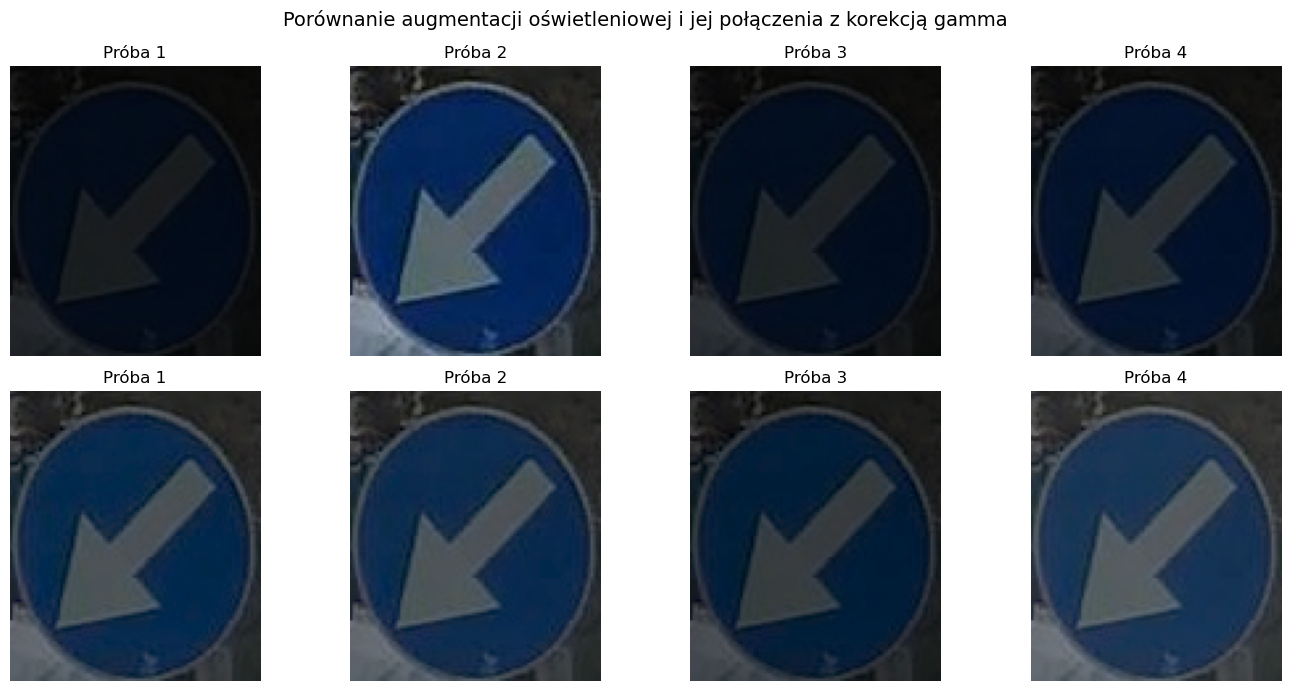

In [6]:
sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = Image.open(
    sample_path
).convert("RGB")


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)


for row_index, configuration in enumerate(
    CONFIGURATIONS
):

    for col_index in range(4):

        image = sample_image


        lighting = (
            RandomLightingAugmentation(
                brightness_range=(
                    0.3,
                    1.3,
                ),

                contrast_range=(
                    0.8,
                    1.2,
                ),

                probability=1.0,
            )
        )


        image = lighting(
            image
        )


        if configuration[
            "use_gamma"
        ]:

            image = gamma_correction(
                image,
                gamma=configuration[
                    "gamma"
                ],
            )


        axes[
            row_index,
            col_index
        ].imshow(
            image
        )


        axes[
            row_index,
            col_index
        ].set_title(
            f"Próba {col_index + 1}"
        )


        axes[
            row_index,
            col_index
        ].axis(
            "off"
        )


    axes[
        row_index,
        0
    ].set_ylabel(
        configuration[
            "name"
        ],
        fontsize=10,
    )


fig.suptitle(
    "Porównanie augmentacji "
    "oświetleniowej i jej połączenia "
    "z korekcją gamma",
    fontsize=14,
)


plt.tight_layout()
plt.show()

## 5. Przygotowanie DataLoaderów

In [7]:
def build_loaders(
    configuration,
):

    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=(
                build_train_transform(
                    configuration
                )
            ),
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=(
                build_eval_transform(
                    use_gamma=(
                        configuration[
                            "use_gamma"
                        ]
                    ),

                    gamma=(
                        1.5
                        if configuration[
                            "gamma"
                        ] is None
                        else configuration[
                            "gamma"
                        ]
                    ),
                )
            ),
        )
    )


    weighted_sampler = (
        build_weighted_sampler(
            TRAIN_PATH
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=weighted_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    )

## 6. Model ResNet50

In [8]:
def create_model():

    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=PRETRAINED,
    )


    model = (
        freeze_resnet50_backbone(
            model
        )
    )


    model = model.to(
        DEVICE
    )


    return model

## 7. Trening pojedynczej konfiguracji

Obie konfiguracje są trenowane według tej samej procedury.

Jedyną zmienną eksperymentalną jest obecność korekcji gamma γ = 1.5.

In [9]:
def train_configuration(
    configuration,
):

    name = configuration[
        "name"
    ]


    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Konfiguracja: {name}"
    )

    print(
        "=" * 80
    )


    set_seed(
        RANDOM_SEED
    )


    (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    ) = build_loaders(
        configuration
    )


    model = create_model()


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FROZEN_LR,
    )


    frozen_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"gamma_lighting_"
            f"{name}_"
            f"frozen_best.pt"
        )
    )


    frozen_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FROZEN_EPOCHS,
        checkpoint_path=frozen_checkpoint,
    )


    model = (
        unfreeze_resnet50_last_block(
            model
        )
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FINE_TUNE_LR,
    )


    finetuned_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"gamma_lighting_"
            f"{name}_"
            f"finetuned_best.pt"
        )
    )


    finetune_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FINE_TUNE_EPOCHS,
        checkpoint_path=finetuned_checkpoint,
    )


    model.eval()


    return {
        "configuration":
            configuration,

        "model":
            model,

        "train_loader":
            train_loader,

        "validation_loader":
            validation_loader,

        "frozen_history":
            frozen_history,

        "finetune_history":
            finetune_history,
    }

## 8. Trening obu konfiguracji

In [10]:
experiments = {}


for configuration in CONFIGURATIONS:

    result = train_configuration(
        configuration
    )


    experiments[
        configuration["name"]
    ] = result


print(
    "\nTrening zakończony."
)


Konfiguracja: lighting_strong_dark


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu:   0%|          | 0/2 [00:00<?, ?it/s]

Epoka 1/2:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/2:   0%|          | 0/445 [00:00<?, ?it/s]


Trening zakończony.


## 9. Standardowa skuteczność na zbiorze walidacyjnym

In [11]:
standard_results = []


for name, experiment in (
    experiments.items()
):

    y_true, y_pred, inference_time = (
        predict(
            experiment[
                "model"
            ],
            experiment[
                "validation_loader"
            ],
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    standard_results.append(
        {
            "configuration":
                name,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "inference_time_seconds":
                inference_time,
        }
    )


standard_validation_df = (
    pd.DataFrame(
        standard_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)


display(
    standard_validation_df
)

,configuration,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,lighting_strong_dark,0.896497,0.883796,0.910128,0.891484,197.37924
1,lighting_strong_dark_gamma_1.5,0.895303,0.873797,0.908340,0.883481,198.71944


## 10. Funkcja oceny kontrolowanego zaciemnienia

In [12]:
def evaluate_lighting_variant(
    model,
    configuration,
    variant,
):

    gamma_enabled = (
        configuration[
            "use_gamma"
        ]
    )


    gamma_value = (
        1.5
        if configuration[
            "gamma"
        ] is None
        else configuration[
            "gamma"
        ]
    )


    transform = (
        build_eval_transform(
            use_gamma=gamma_enabled,
            gamma=gamma_value,
        )
    )


    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

## 11. Ocena odporności na zaciemnienie

In [13]:
dark_results = []


for name, experiment in (
    experiments.items()
):

    model = experiment[
        "model"
    ]


    configuration = experiment[
        "configuration"
    ]


    for variant in DARK_VARIANTS:

        print(
            f"{name} | {variant}"
        )


        metrics = (
            evaluate_lighting_variant(
                model=model,
                configuration=configuration,
                variant=variant,
            )
        )


        dark_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **metrics,
            }
        )


dark_results_df = (
    pd.DataFrame(
        dark_results
    )
)


display(
    dark_results_df
)

lighting_strong_dark | dark_1
lighting_strong_dark | dark_2
lighting_strong_dark | dark_3
lighting_strong_dark_gamma_1.5 | dark_1
lighting_strong_dark_gamma_1.5 | dark_2
lighting_strong_dark_gamma_1.5 | dark_3


,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,lighting_strong_dark,dark_1,0.7,2512,0.896497,0.893811,0.922634,0.903839,201.453886
1,lighting_strong_dark,dark_2,0.5,2512,0.886943,0.870697,0.902027,0.879837,204.343177
2,lighting_strong_dark,dark_3,0.3,2512,0.870223,0.852861,0.891371,0.863060,222.358394
3,lighting_strong_dark_gamma_1.5,dark_1,0.7,2512,0.896099,0.887147,0.904454,0.889615,218.546207
4,lighting_strong_dark_gamma_1.5,dark_2,0.5,2512,0.893710,0.870979,0.902661,0.880172,214.812268
5,lighting_strong_dark_gamma_1.5,dark_3,0.3,2512,0.884952,0.866580,0.895867,0.873437,212.896440


## 12. Podsumowanie odporności

In [14]:
dark_summary = (
    dark_results_df
    .groupby(
        "configuration"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
)


dark3 = (
    dark_results_df[
        dark_results_df[
            "variant"
        ] == "dark_3"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


standard = (
    standard_validation_df[
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


robustness_summary = (
    dark_summary
    .join(
        dark3
    )
    .join(
        standard
    )
)


robustness_summary[
    "f1_drop_to_dark3"
] = (
    robustness_summary[
        "standard_macro_f1"
    ]
    -
    robustness_summary[
        "dark3_macro_f1"
    ]
)


robustness_summary = (
    robustness_summary
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    robustness_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,,
lighting_strong_dark,0.882245,0.884554,0.863060,0.891484,0.028425
lighting_strong_dark_gamma_1.5,0.881075,0.891587,0.873437,0.883481,0.010044


## 13. Porównanie poziomów zaciemnienia

configuration,lighting_strong_dark,lighting_strong_dark_gamma_1.5
variant,,
dark_1,0.903839,0.889615
dark_2,0.879837,0.880172
dark_3,0.863060,0.873437


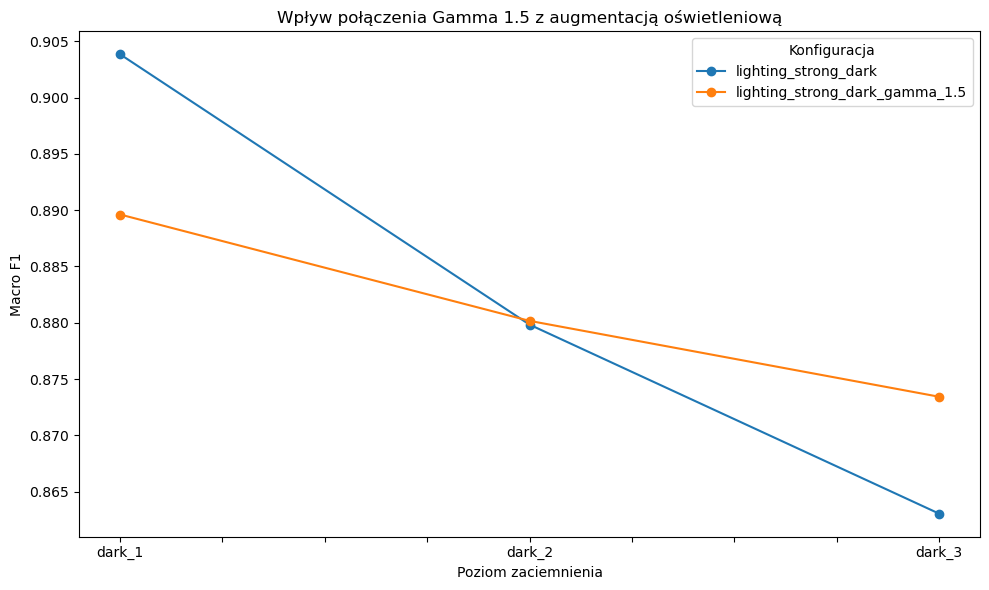

In [15]:
dark_plot = (
    dark_results_df
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
    .reindex(
        DARK_VARIANTS
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Wpływ połączenia Gamma 1.5 "
    "z augmentacją oświetleniową"
)

ax.set_xlabel(
    "Poziom zaciemnienia"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Konfiguracja"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_gamma_lighting_dark_comparison.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 14. Wybór ostatecznej konfiguracji

Na podstawie wyników walidacyjnych dokonano wyboru konfiguracji przeznaczonej do końcowej oceny na niezależnym zbiorze `test_final`.

Podstawowym kryterium pozostaje średnia wartość `Macro F1` dla trzech poziomów zaciemnienia. W przypadku bardzo małej różnicy pomiędzy konfiguracjami uwzględniono dodatkowo:

- wartość `Macro F1` dla najsilniejszego zaciemnienia `dark_3`,
- średnią dokładność dla warunków zaciemnienia,
- spadek `Macro F1` pomiędzy warunkiem oryginalnym a `dark_3`.

Takie podejście pozwala uwzględnić nie tylko średnią skuteczność, ale również stabilność modelu wraz ze wzrostem niekorzystnych warunków oświetleniowych.

Wybór końcowej konfiguracji jest dokonywany wyłącznie na podstawie zbioru walidacyjnego.

In [21]:
comparison = robustness_summary.copy()


comparison["mean_dark_macro_f1_rank"] = (
    comparison[
        "mean_dark_macro_f1"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)


comparison["dark3_macro_f1_rank"] = (
    comparison[
        "dark3_macro_f1"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)


comparison["mean_dark_accuracy_rank"] = (
    comparison[
        "mean_dark_accuracy"
    ]
    .rank(
        ascending=False,
        method="min",
    )
)


comparison["f1_drop_rank"] = (
    comparison[
        "f1_drop_to_dark3"
    ]
    .rank(
        ascending=True,
        method="min",
    )
)


comparison[
    "stability_score"
] = (
    comparison[
        "dark3_macro_f1_rank"
    ]
    +
    comparison[
        "mean_dark_accuracy_rank"
    ]
    +
    comparison[
        "f1_drop_rank"
    ]
)


display(
    comparison[
        [
            "mean_dark_macro_f1",
            "dark3_macro_f1",
            "mean_dark_accuracy",
            "standard_macro_f1",
            "f1_drop_to_dark3",
            "stability_score",
        ]
    ]
)

,mean_dark_macro_f1,dark3_macro_f1,mean_dark_accuracy,standard_macro_f1,f1_drop_to_dark3,stability_score
configuration,,,,,,
lighting_strong_dark,0.882245,0.863060,0.884554,0.891484,0.028425,6.0
lighting_strong_dark_gamma_1.5,0.881075,0.873437,0.891587,0.883481,0.010044,3.0


## 15. Ocena różnicy pomiędzy konfiguracjami

Różnica średniego `Macro F1` dla warunków zaciemnienia jest niewielka. W takiej sytuacji sama wartość średnia nie jest wystarczającą podstawą do wyboru konfiguracji.

Szczególne znaczenie przypisano zachowaniu modelu dla `dark_3`, ponieważ wariant ten reprezentuje najtrudniejsze kontrolowane warunki oświetleniowe.

## 16. Uzasadnienie wyboru konfiguracji

Konfigurację `lighting_strong_dark + gamma_1.5` uznano za bardziej korzystną z punktu widzenia celu badania, pomimo minimalnie niższej średniej wartości `Macro F1` dla trzech poziomów zaciemnienia.

Konfiguracja z korekcją gamma uzyskała wyższą wartość `Macro F1` dla najsilniejszego zaciemnienia oraz mniejszy spadek skuteczności względem obrazu oryginalnego.

Oznacza to większą stabilność klasyfikacji wraz ze wzrostem stopnia zaciemnienia.

In [23]:
selected_configuration = (
    "lighting_strong_dark_gamma_1.5"
)


selected_configuration_metrics = (
    robustness_summary.loc[
        selected_configuration
    ]
)


print(
    "Ostatecznie wybrana konfiguracja:"
)

print(
    selected_configuration
)


display(
    selected_configuration_metrics
)

Ostatecznie wybrana konfiguracja:
lighting_strong_dark_gamma_1.5


mean_dark_macro_f1    0.881075
mean_dark_accuracy    0.891587
dark3_macro_f1        0.873437
standard_macro_f1     0.883481
f1_drop_to_dark3      0.010044
Name: lighting_strong_dark_gamma_1.5, dtype: float64

## 17. Parametry wybranej konfiguracji

Wybrany pipeline wykorzystuje:

- model ResNet50,
- `WeightedRandomSampler`,
- augmentację oświetleniową z zakresem jasności 0.3–1.3,
- augmentację kontrastu w zakresie 0.8–1.2,
- prawdopodobieństwo augmentacji 0.8,
- korekcję gamma γ = 1.5,
- funkcję Cross Entropy.

Konfiguracja zostanie poddana końcowej ocenie na niezależnym zbiorze `test_final`.

## 20. Podsumowanie decyzji

Na podstawie wyników walidacyjnych do końcowej oceny wybrano konfigurację:

`ResNet50 + WeightedRandomSampler + Lighting Augmentation + Gamma 1.5 + Cross Entropy`.

Decyzję uzasadnia większa stabilność modelu przy wzroście stopnia zaciemnienia oraz wyższy wynik `Macro F1` dla najsilniejszego wariantu `dark_3`, przy jednocześnie bardzo zbliżonej średniej wartości `Macro F1` dla wszystkich wariantów zaciemnienia.

Dalsza ocena konfiguracji zostanie wykonana na niezależnym zbiorze `test_final`.